In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics / Outlier detection
from scipy.stats import zscore


%matplotlib inline

In [2]:
df = pd.read_csv('house_price.csv')

In [3]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


In [5]:
df.describe

<bound method NDFrame.describe of                        location       size  total_sqft  bath   price  bhk  \
0      Electronic City Phase II      2 BHK      1056.0   2.0   39.07    2   
1              Chikka Tirupathi  4 Bedroom      2600.0   5.0  120.00    4   
2                   Uttarahalli      3 BHK      1440.0   2.0   62.00    3   
3            Lingadheeranahalli      3 BHK      1521.0   3.0   95.00    3   
4                      Kothanur      2 BHK      1200.0   2.0   51.00    2   
...                         ...        ...         ...   ...     ...  ...   
13195                Whitefield  5 Bedroom      3453.0   4.0  231.00    5   
13196                     other      4 BHK      3600.0   5.0  400.00    4   
13197     Raja Rajeshwari Nagar      2 BHK      1141.0   2.0   60.00    2   
13198           Padmanabhanagar      4 BHK      4689.0   4.0  488.00    4   
13199              Doddathoguru      1 BHK       550.0   1.0   17.00    1   

       price_per_sqft  
0                

In [6]:
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [7]:
df['price_per_sqft'] = (df['price']*100000) / df['total_sqft']

In [8]:
mean = df['price_per_sqft'].mean()
std = df['price_per_sqft'].std()

lower = mean - 3*std
upper = mean + 3*std

df_std = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

In [9]:
lower = df['price_per_sqft'].quantile(0.05)
upper = df['price_per_sqft'].quantile(0.95)

df_percentile = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

In [10]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df_iqr = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

In [11]:
from scipy.stats import zscore

df['zscore'] = zscore(df['price_per_sqft'])

df_z = df[(df['zscore'] > -3) & (df['zscore'] < 3)]

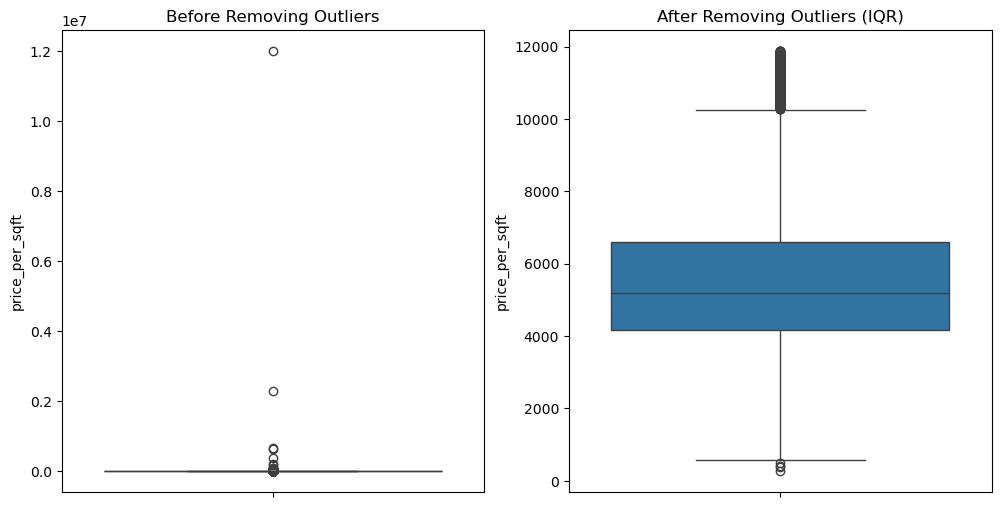

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.boxplot(df['price_per_sqft'])
plt.title("Before Removing Outliers")

plt.subplot(1,2,2)
sns.boxplot(df_iqr['price_per_sqft'])  # try others too
plt.title("After Removing Outliers (IQR)")

plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

# Before transformation
print("Skewness:", skew(df['price_per_sqft']))
print("Kurtosis:", kurtosis(df['price_per_sqft']))

sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Before Transformation")
plt.show()

Skewness: 108.26875399964703
Kurtosis: 12090.634145107531


In [ ]:
df['log_price_per_sqft'] = np.log(df['price_per_sqft'])

print("After Transformation:")
print("Skewness:", skew(df['log_price_per_sqft']))
print("Kurtosis:", kurtosis(df['log_price_per_sqft']))

sns.histplot(df['log_price_per_sqft'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Price vs Total Sqft")
plt.show()

sns.scatterplot(x='bath', y='price', data=df)
plt.title("Price vs Bathrooms")
plt.show()

Performed EDA to understand dataset structure

Detected outliers using:

- Mean & Std Dev
Percentile method
IQR method
Z-score
IQR method performed best for skewed housing data

Applied log transformation to normalize distribution

Observed correlation using heatmap

Verified relationships using scatter plots